In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import torch
import io
from IPython.display import display, Markdown, HTML
from collections import Counter
from scipy.signal import cheby2, sosfiltfilt
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
import pywt

In [3]:
class report_helper:

    def __init__(self, data, name="Tín hiệu ECG"):
        if isinstance(data, pd.Series):
            self.df = data.to_frame()
        elif isinstance(data, pd.DataFrame):
            self.df = data
        else:
            self.df = pd.DataFrame(data, columns=[name])

        self.name = name

    def _print_header(self, text):
        display(Markdown(f"<br><b><font size='4' color='#1F618D'> {text}</font></b>"))
        display(HTML("<hr style='height:2px; border:none; background-color:#D5D8DC; margin-top:2px; margin-bottom:10px;'>"))

    def show_head(self, n=5):
        self._print_header(f"1. MẪU DỮ LIỆU ({n} DÒNG ĐẦU)")
        display(self.df.head(n))

    def show_info(self):
        self._print_header("2. THÔNG TIN TỔNG QUAN (Cấu trúc & Dữ liệu khuyết thiếu)")
        buffer = io.StringIO()
        self.df.info(buf=buffer)
        info_str = buffer.getvalue()

        display(Markdown(f"```text\n{info_str}\n```"))

    def show_describe(self):
        self._print_header("3. THỐNG KÊ MÔ TẢ (Describe)")
        display(self.df.describe().T)

    def run_all(self):
        display(Markdown(f"##BÁO CÁO KHÁM PHÁ DỮ LIỆU: `{self.name}`"))
        self.show_head()
        self.show_info()
        self.show_describe()
        print("\nHoàn tất báo cáo!")


In [4]:
SIGNAL_PATH = "/content/drive/MyDrive/Colab Notebooks/100_ekg.csv"
ANNOT_PATH  = "/content/drive/MyDrive/Colab Notebooks/100_annotations_1.csv"

signal = pd.read_csv(SIGNAL_PATH)
annot = pd.read_csv(ANNOT_PATH)

signal_reporter = report_helper(signal, "RAW SIGNAL")
annot_reporter = report_helper(annot, "ANNOTATION")

In [5]:
signal_reporter.run_all()

##BÁO CÁO KHÁM PHÁ DỮ LIỆU: `RAW SIGNAL`

<br><b><font size='4' color='#1F618D'> 1. MẪU DỮ LIỆU (5 DÒNG ĐẦU)</font></b>

,Unnamed: 0,MLII,V5,symbol
0,0,-0.145,-0.065,NaN
1,1,-0.145,-0.065,NaN
2,2,-0.145,-0.065,NaN
3,3,-0.145,-0.065,NaN
4,4,-0.145,-0.065,NaN


<br><b><font size='4' color='#1F618D'> 2. THÔNG TIN TỔNG QUAN (Cấu trúc & Dữ liệu khuyết thiếu)</font></b>

```text
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650000 entries, 0 to 649999
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  650000 non-null  int64  
 1   MLII        650000 non-null  float64
 2   V5          650000 non-null  float64
 3   symbol      2274 non-null    object 
dtypes: float64(2), int64(1), object(1)
memory usage: 19.8+ MB

```

<br><b><font size='4' color='#1F618D'> 3. THỐNG KÊ MÔ TẢ (Describe)</font></b>

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,650000.0,324999.500000,187638.981824,0.000,162499.750,324999.500,487499.250,649999.000
MLII,650000.0,-0.306299,0.193200,-2.715,-0.390,-0.335,-0.270,1.435
V5,650000.0,-0.191034,0.148213,-2.465,-0.265,-0.205,-0.145,1.225



Hoàn tất báo cáo!


In [6]:
annot_reporter.run_all()

##BÁO CÁO KHÁM PHÁ DỮ LIỆU: `ANNOTATION`

<br><b><font size='4' color='#1F618D'> 1. MẪU DỮ LIỆU (5 DÒNG ĐẦU)</font></b>

,index,annotation_symbol
0,18,+
1,77,N
2,370,N
3,662,N
4,946,N


<br><b><font size='4' color='#1F618D'> 2. THÔNG TIN TỔNG QUAN (Cấu trúc & Dữ liệu khuyết thiếu)</font></b>

```text
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2274 entries, 0 to 2273
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   index              2274 non-null   int64 
 1   annotation_symbol  2274 non-null   object
dtypes: int64(1), object(1)
memory usage: 35.7+ KB

```

<br><b><font size='4' color='#1F618D'> 3. THỐNG KÊ MÔ TẢ (Describe)</font></b>

,count,mean,std,min,25%,50%,75%,max
index,2274.0,324688.717238,187967.153104,18.0,162103.25,322424.0,487645.0,649991.0



Hoàn tất báo cáo!


### Xử lý nhiễu tín hiệu (Chebyshev II filter và Wavelet Daubechies)

In [7]:
def cheby2_bandpass_filter(signal, fs=360, lowcut=0.5, highcut=48, order=4, rs=40):

  nyq = 0.5 * fs
  low = lowcut / nyq
  high = highcut / nyq

  sos = cheby2(order, rs, [low, high], btype='bandpass', output='sos')

  padlen = min(len(signal) - 1, 100)
  filtered = sosfiltfilt(sos, signal, padlen=padlen)

  return filtered


def wavelet_denoise(signal, wavelet='db4', level=6):

  try:
    coeffs = pywt.wavedec(signal, wavelet, level=level)

  except ValueError:
    max_level = pywt.dwt_max_level(len(signal), wavelet)
    level = min(level, max_level)
    coeffs = pywt.wavedec(signal, wavelet, level=level)

  cA = coeffs[0]
  cDs = coeffs[1:]

  sigma = np.median(np.abs(cDs[-1])) / 0.6745
  base_thresh = sigma * np.sqrt(2 * np.log(len(signal))) * 0.8
  num_levels = len(cDs)

  new_cDs = []
  for i, cD in enumerate(cDs):
      if i >= num_levels - 3:
          scale = (i - (num_levels - 3) + 1) / 3
          thresh = base_thresh * scale
          new_cD = pywt.threshold(cD, thresh, mode='soft')
      else:
          new_cD = cD
      new_cDs.append(new_cD)
  new_coeffs = [cA] + new_cDs
  denoised = pywt.waverec(new_coeffs, wavelet)

  if denoised is not None:
    return denoised[:len(signal)]
  else:
    return signal


def preprocess_signal(signal, fs=360):

  filtered = cheby2_bandpass_filter(signal, fs)
  denoised = wavelet_denoise(filtered)

  return denoised

### Mapping annotations

In [8]:
PATIENT_IDS = [
    '100', '101', '103', '105', '106', '108', '109', '111', '112', '113',
    '114', '115', '116', '117', '118', '119', '121', '122', '123', '124',
    '200', '201', '202', '203', '205', '207', '208', '209', '210', '212',
    '213', '214', '215', '219', '220', '221', '222', '223', '228', '230',
    '231', '232', '233', '234'
]

VALID_SYMBOLS = {
    'N','L','R','e','j','·','n',
    'A','a','J','S',
    'V','E','r',
    'F'
}

AAMI_MAP = {
    'N': 'N','L': 'N','R': 'N','e': 'N','j': 'N','·':'N','n':'N',
    'A': 'S','a': 'S','J': 'S','S': 'S',
    'V': 'V','E': 'V','r':'V',
    'F': 'V',
}

CLASS_TO_IDX = {'N':0, 'S':1, 'V':2}

IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}


def filter_valid_beats(r_index, labels):

    clean_r = []
    clean_labels = []

    for r, l in zip(r_index, labels):
        if l in VALID_SYMBOLS:
            clean_r.append(r)
            clean_labels.append(l)

    return np.array(clean_r), np.array(clean_labels)

def map_to_aami(labels):

    return np.array([CLASS_TO_IDX[AAMI_MAP[l]] for l in labels])

### Processing patients

In [9]:
def load_patient_data(patient_id, data_dir):

    signal_path = f"{data_dir}/{patient_id}_ekg.csv"
    ann_path = f"{data_dir}/{patient_id}_annotations_1.csv"

    df_signal = pd.read_csv(signal_path)

    if 'MLII' in df_signal.columns:
        signal = df_signal['MLII'].values
    else:
        signal = df_signal.iloc[:, 0].values

    ann = pd.read_csv(ann_path)
    r_index = ann['index'].values
    labels = ann['annotation_symbol'].values

    return signal, r_index, labels


def split_patients(patient_ids, test_size=0.2, random_state=42):

    train_ids, test_ids = train_test_split(
        patient_ids,
        test_size=test_size,
        random_state=random_state
    )

    return train_ids, test_ids


def process_patient(signal, r_index, labels):

    signal_filtered = preprocess_signal(signal)

    r_index, labels = filter_valid_beats(r_index, labels)
    rr, valid_r_exrr, valid_idx_exrr = extract_rr_feature(r_index)
    beats, valid_idx_seg, valid_rr_seg = segment_norm_signal(signal_filtered, valid_r_exrr, valid_idx_exrr, rr)

    labels = labels[valid_idx_seg]
    labels = map_to_aami(labels)

    return beats, valid_rr_seg, labels


def build_dataset(patient_ids, data_dir):

    all_beats, all_rr, all_labels = [], [], []

    for pid in patient_ids:

        try:
            signal, r_index, labels = load_patient_data(pid, data_dir)
            beats, rr, y = process_patient(signal, r_index, labels)

            all_beats.append(beats)
            all_rr.append(rr)
            all_labels.append(y)

        except Exception as e:
            print(f"Bỏ qua bệnh nhân {pid} do lỗi dữ liệu: {e}")
            continue

    X = np.concatenate(all_beats)
    RR = np.concatenate(all_rr)
    y = np.concatenate(all_labels)

    return X, RR, y

### Extract RR

In [10]:
def extract_rr_feature(r_index, fs=360):

    all_rr_interval = np.diff(r_index)

    rr_feature = []
    valid_r = []
    valid_idx = []

    for i in range(5, len(r_index) - 5):
        rr_pre = all_rr_interval[i - 1] / fs
        rr_post = all_rr_interval[i] / fs
        rr_avg = np.mean(all_rr_interval[i - 5: i + 5]) / fs

        rr_feature.append([rr_pre, rr_post, rr_avg])

        valid_r.append(r_index[i])
        valid_idx.append(i)

    return np.array(rr_feature), np.array(valid_r), np.array(valid_idx)

### Segment beat

In [11]:
def segment_norm_signal(signal, valid_r, valid_r_idx, rr_features, eps=1e-8):

    beats = []
    valid_idx = []
    valid_rr = []

    for i, (idx, r) in enumerate(zip(valid_r_idx, valid_r)):
        if r - 100 < 0 or r + 200 > len(signal):
            continue
        beats.append(signal[r - 100 : r + 200])
        valid_idx.append(idx)
        valid_rr.append(rr_features[i])

    if not beats:
        return np.array([]), np.array([]), np.array([])

    beats_array = np.array(beats)
    mean = np.mean(beats_array, axis=1, keepdims=True)
    std = np.std(beats_array, axis=1, keepdims=True)
    std = np.maximum(std, eps)

    beat_normalized = (beats_array - mean) / std

    return beat_normalized, np.array(valid_idx), np.array(valid_rr)

### Bootstrapping

In [12]:
def apply_bootstrapping(X_beats, X_rr, y, target_samples=30000, random_state=42):

    print(f"Bắt đầu Bootstrapping ép mỗi lớp về {target_samples} mẫu...")
    classes = np.unique(y)

    X_beats_bal, X_rr_bal, y_bal = [], [], []

    for cls in classes:

        idx_cls = np.where(y == cls)[0]

        replace_flag = len(idx_cls) < target_samples

        beats_res, rr_res, y_res = resample(
            X_beats[idx_cls],
            X_rr[idx_cls],
            y[idx_cls],
            replace=replace_flag,
            n_samples=target_samples,
            random_state=random_state
        )

        X_beats_bal.append(beats_res)
        X_rr_bal.append(rr_res)
        y_bal.append(y_res)

        print(f" - Lớp {cls}: Từ {len(idx_cls)} -> {target_samples} mẫu.")

    return np.vstack(X_beats_bal), np.vstack(X_rr_bal), np.concatenate(y_bal)

### Main

In [16]:
def load_patient(signal_path, annot_path):
    print("\nLoading data...")

    signal_df = pd.read_csv(signal_path)
    annot_df = pd.read_csv(annot_path)

    signal = pd.to_numeric(signal_df.iloc[:, 0], errors='coerce').values
    r_index = annot_df['index'].values
    labels = annot_df['annotation_symbol'].values

    print(f"Signal shape: {signal.shape}")
    print(f"R index shape: {r_index.shape}")
    print(f"Labels shape: {labels.shape}")
    return signal, r_index, labels

def print_distribution(y, name):
    counter = Counter(y)
    print(f"\nDistribution - {name}:")
    total = len(y)
    for k in sorted(counter.keys()):
        print(f"  Class {k}: {counter[k]} ({counter[k]/total:.2%})")


def sanity_check(X, RR, y, name):
    print(f"\nSanity Check: {name}")

    print(f"Beats shape: {X.shape}")
    print(f"RR shape:    {RR.shape}")
    print(f"Labels:      {y.shape}")

    assert len(X) == len(RR) == len(y), "Length mismatch!"
    assert X.shape[1] == 300, "Beat length != 300"
    assert RR.shape[1] == 3, "RR feature != 3"

    assert not np.isnan(X).any(), "NaN in beats"
    assert not np.isnan(RR).any(), "NaN in RR"

    print("✔ Passed")


def visualize_signal(signal, title="Signal", start=0, end=1800):
    plt.figure(figsize=(12, 4))
    plt.plot(signal[start:end])
    plt.title(title)
    plt.show()


def visualize_random_beats(X, title, num_samples=5):
    plt.figure(figsize=(12, 4))
    for _ in range(num_samples):
        idx = np.random.randint(0, len(X))
        plt.plot(X[idx], alpha=0.7)
    plt.title(title)
    plt.show()

def debug_single_patient(signal_path, annot_path):

    signal, r_index, labels = load_patient(signal_path, annot_path)
    visualize_signal(signal, "Raw ECG (5s)")
    print("\nProcessing patient...")

    beats, rr, y = process_patient(signal, r_index, labels)
    sanity_check(beats, rr, y, "AFTER PROCESS")
    print_distribution(y, "AFTER PROCESS")

    visualize_random_beats(beats, "Random beats after preprocessing")
    print("\nRR Features Check:")

    print("First 5 RR:")
    print(rr[:5])

    print("\nRR stats:")
    print("Mean:", rr.mean(axis=0))
    print("Std :", rr.std(axis=0))

    print("\nExtra Debug:")

    print("Unique labels:", np.unique(y))

    print("Beat mean:", beats.mean())
    print("Beat std :", beats.std())

    print("\nSINGLE PATIENT DEBUG DONE")


Loading data...
Signal shape: (650000,)
R index shape: (2274,)
Labels shape: (2274,)


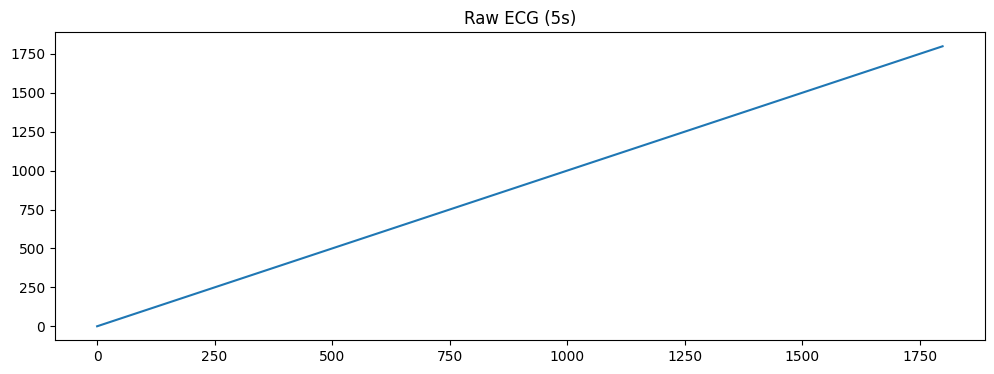


Processing patient...

Sanity Check: AFTER PROCESS
Beats shape: (2263, 300)
RR shape:    (2263, 3)
Labels:      (2263,)
✔ Passed

Distribution - AFTER PROCESS:
  Class 0: 2229 (98.50%)
  Class 1: 33 (1.46%)
  Class 2: 1 (0.04%)


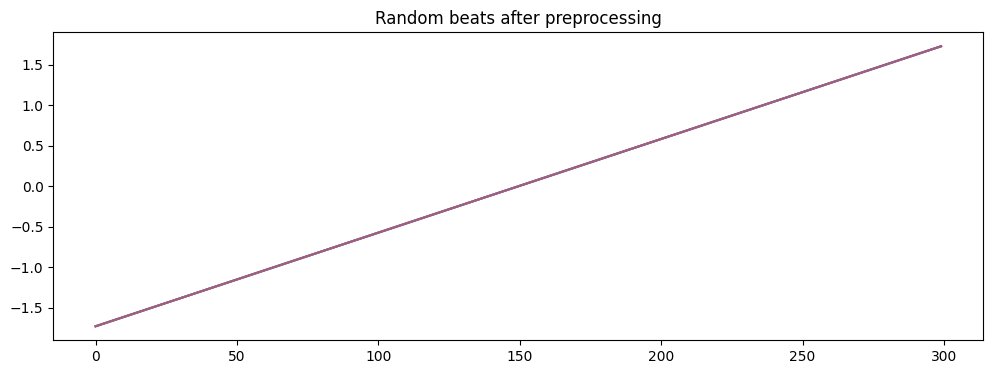


RR Features Check:
First 5 RR:
[[0.78888889 0.81666667 0.81138889]
 [0.81666667 0.65277778 0.80888889]
 [0.65277778 0.99444444 0.805     ]
 [0.99444444 0.84444444 0.81      ]
 [0.84444444 0.81111111 0.81638889]]

RR stats:
Mean: [0.79479305 0.79474518 0.79475082]
Std : [0.04871882 0.04877779 0.02517207]

Extra Debug:
Unique labels: [0 1 2]
Beat mean: 8.852426819275416e-16
Beat std : 1.0

SINGLE PATIENT DEBUG DONE


In [17]:
debug_single_patient(SIGNAL_PATH, ANNOT_PATH)